33


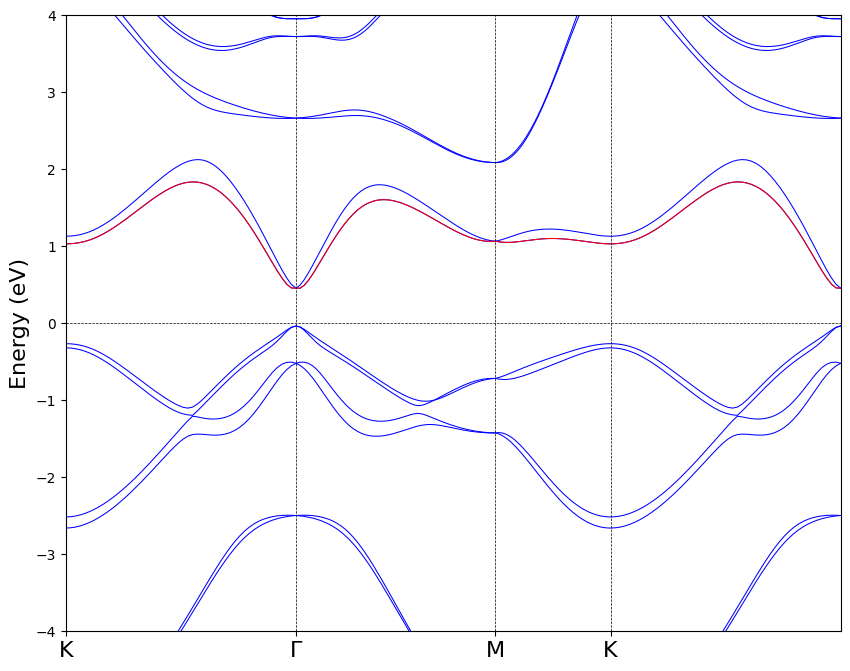

In [16]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.896,1.671,2.119,3.015]  
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

plt.plot(k, bands[:, 18], color='red', lw=0.75)

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)


plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)

plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-4, 4)
plt.xlim(min(k), max(k))
plt.show()

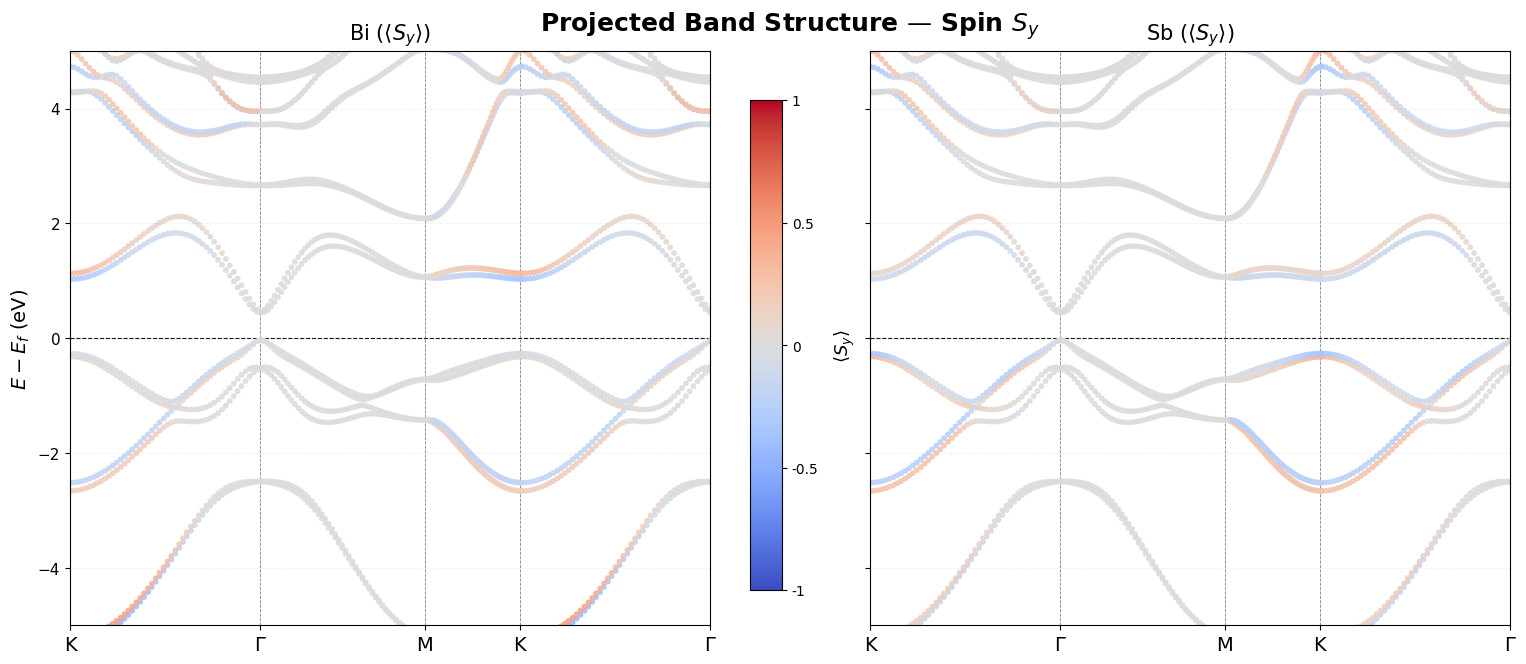

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load Data ---
def load_band_data(filepath):
    return pd.read_csv(filepath, comment='#', sep=r'\s+', header=None, skiprows=2)

data_bi = load_band_data("PBAND_In_SOC_SZ.dat")
data_sb = load_band_data("PBAND_Sb_SOC_SZ.dat")

k = data_bi[0].to_numpy()
e = data_bi[1].to_numpy()

# --- High-symmetry k-points and labels ---
k_points = [0,0.891,1.663,2.109,3.000]   
k_labels = [r'K', r'$\Gamma$', r'M', r'K', r'$\Gamma$']

# --- Normalize to [-1, 1] using global abs max ---
spin_bi = data_bi[11].to_numpy()
spin_sb = data_sb[11].to_numpy()

global_absmax = max(np.abs(spin_bi).max(), np.abs(spin_sb).max())

spin_bi_norm = spin_bi / global_absmax
spin_sb_norm = spin_sb / global_absmax

# --- Shared norm and colormap ---
CMAP = 'coolwarm'
shared_norm = Normalize(vmin=-1, vmax=1)

# --- Plot ---
TITLES = [r'Bi ($\langle S_y \rangle$)', r'Sb ($\langle S_y \rangle$)']
spins  = [spin_bi_norm, spin_sb_norm]

fig = plt.figure(figsize=(16, 7))
fig.suptitle(r"Projected Band Structure — Spin $S_y$", fontsize=18, fontweight='bold')

ax_left  = fig.add_axes([0.05, 0.10, 0.40, 0.82])
ax_right = fig.add_axes([0.55, 0.10, 0.40, 0.82])
ax_cbar  = fig.add_axes([0.475, 0.15, 0.02, 0.70])

axes = [ax_left, ax_right]

for ax, spin, title in zip(axes, spins, TITLES):
    ax.scatter(k, e, c=spin, cmap=CMAP, norm=shared_norm, s=10, alpha=0.85, rasterized=True)

    for xv in k_points[1:-1]:
        ax.axvline(xv, ls='--', lw=0.6, color='gray', zorder=0)

    ax.axhline(0, ls='--', lw=0.8, color='black', zorder=0)
    ax.grid(True, which='major', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_ylim(-5, 5)
    ax.set_xlim(k_points[0], k_points[-1])
    ax.set_xticks(k_points)
    ax.set_xticklabels(k_labels, fontsize=14)
    ax.set_title(title, fontsize=15, pad=8)
    ax.tick_params(axis='y', labelsize=11)

ax_left.set_ylabel(r'$E - E_f$ (eV)', fontsize=14)
ax_right.set_yticklabels([])

# --- Centered colorbar ---
sm = ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\langle S_y \rangle$', fontsize=13, labelpad=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=10)

plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_20096\84205120.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_in = pd.read_csv(r"PBAND_In_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_20096\84205120.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


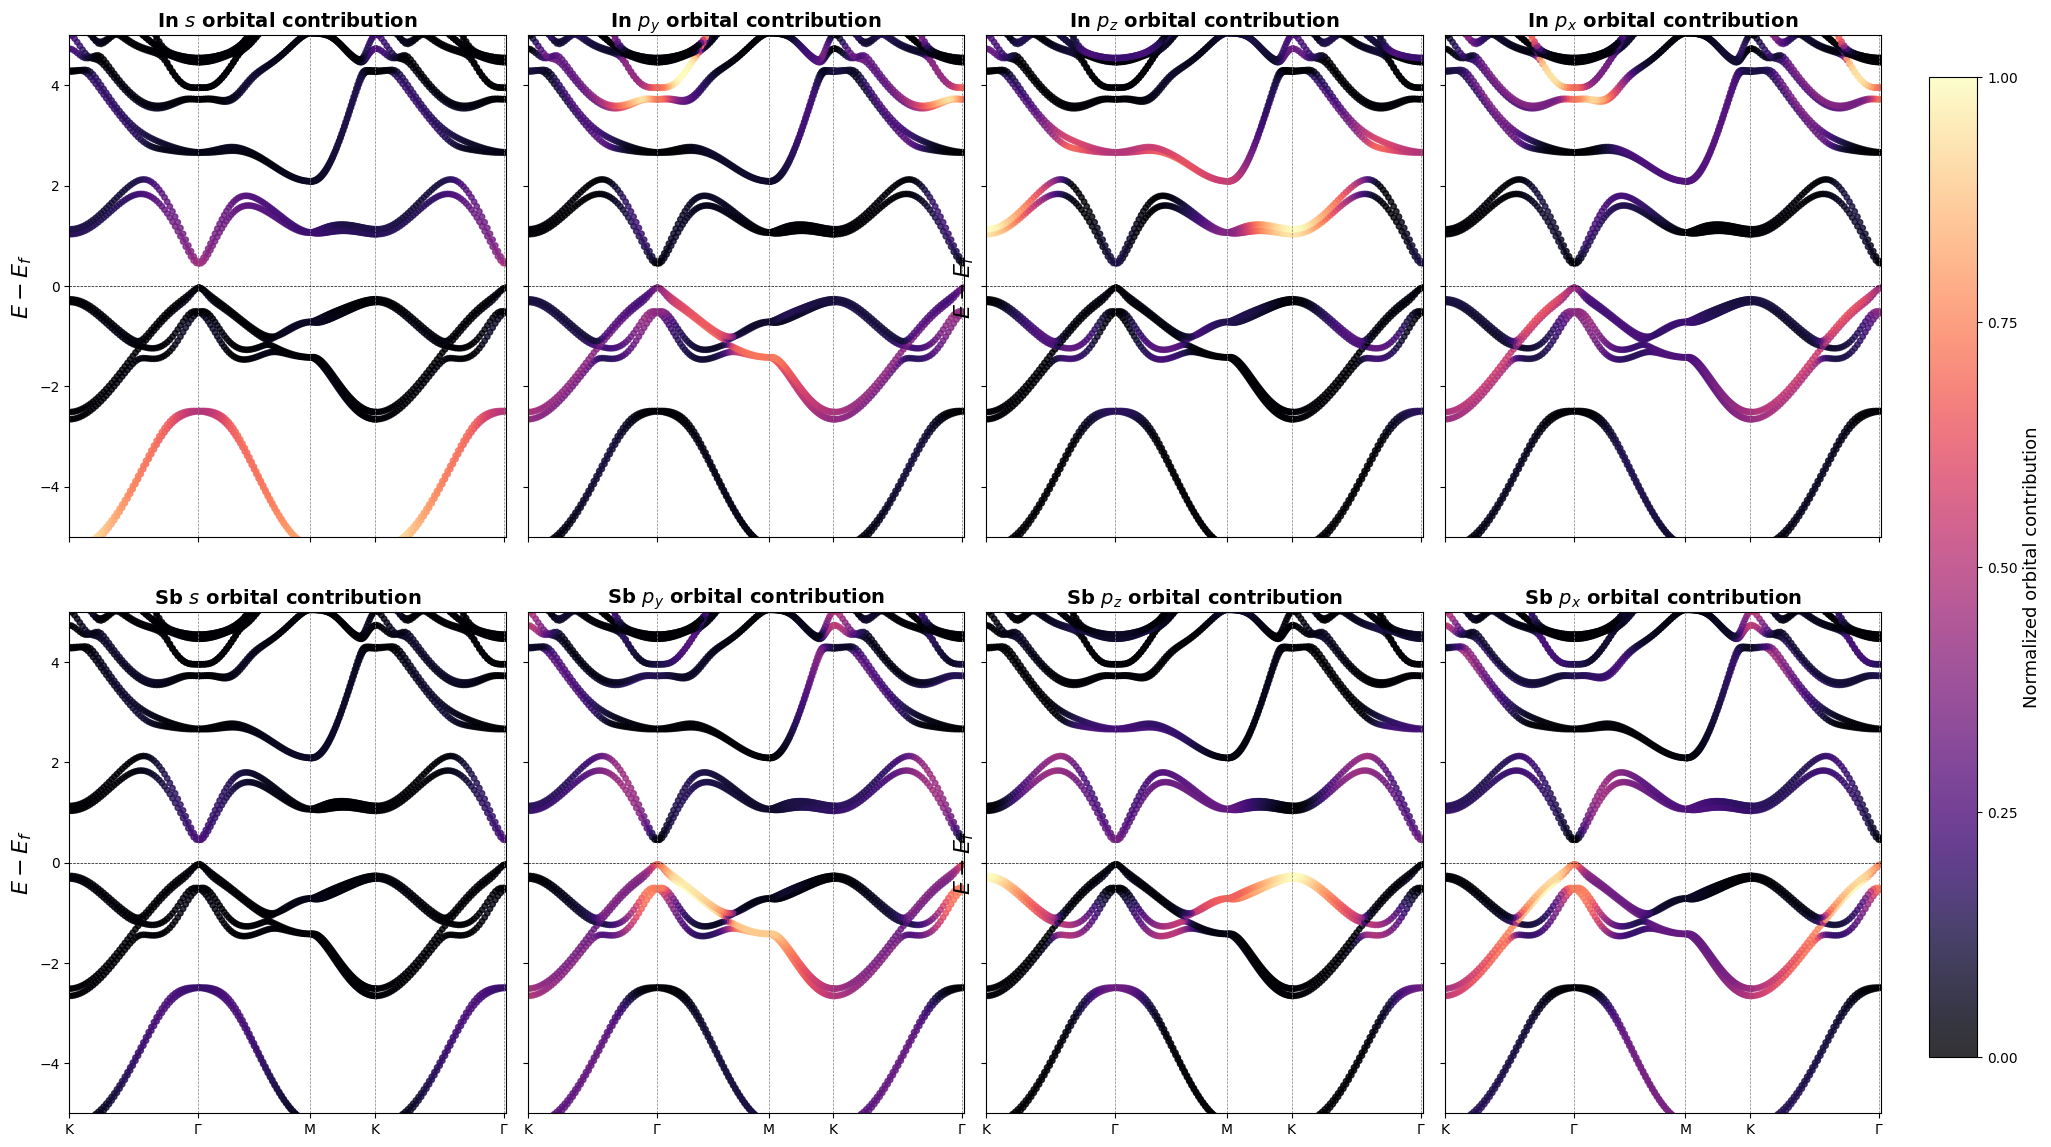

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_in = pd.read_csv(r"PBAND_In_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_Sb_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_in[0])
e = np.array(data_in[1])

# --- Extract raw values ---
in_vals = [data_in[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

in_norms = [local_norm(v) for v in in_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [in_norms[0],in_norms[1], in_norms[2], in_norms[3],
            sb_norms[0],sb_norms[1], sb_norms[2], sb_norms[3]] 

names = ['In $s$', 'In $p_y$', 'In $p_z$', 'In $p_x$',
         'Sb $s$',  'Sb $p_y$', 'Sb $p_z$', 'Sb $p_x$']

cmap     = 'magma'

high_symmetry_points = [0,0.891,1.663,2.109,3.000]  
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=14, fontweight='bold')
    ax.set_ylim(-5, 5)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels)

    # y-axis label only on left column
    if idx % 2 == 0:
        ax.set_ylabel(r'$E-E_f$', fontsize=16)

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution', fontsize=13)
cbar.ax.tick_params(labelsize=10)

plt.show()

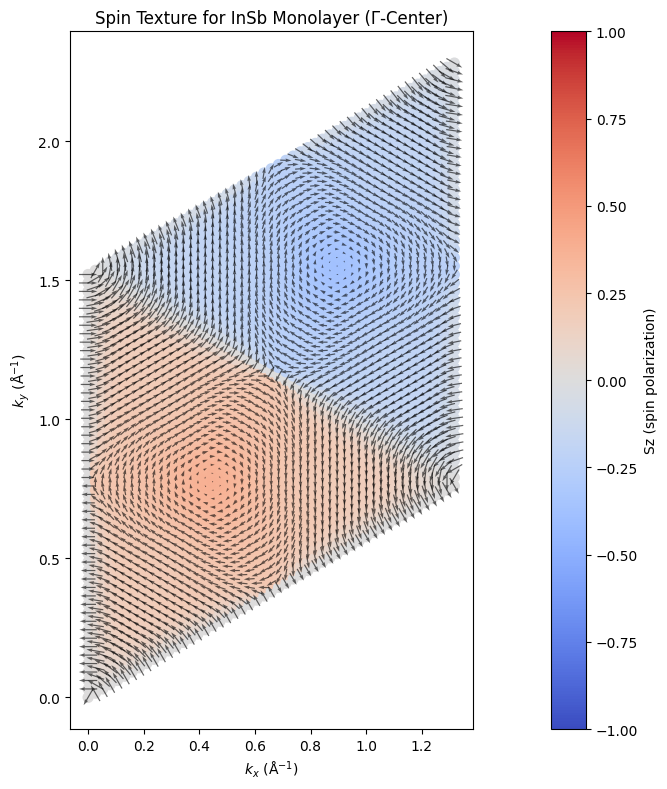

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "SPINTEXTURE_2D.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

fig, ax = plt.subplots(figsize=(16, 8))

# Background: scatter colored by Sz
norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx, ky, c=Sz, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

# Foreground: quiver arrows showing in-plane spin (Sx, Sy)
ax.quiver(kx, ky, Sx, Sy,
          pivot="mid",
          scale=8,          # lower = longer arrows; tune to your grid
          scale_units="xy",
          width=0.003,
          color="black",
          alpha=0.6,
          zorder=2)

ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
ax.set_title("Spin Texture for InSb Monolayer (Γ-Center)")
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()

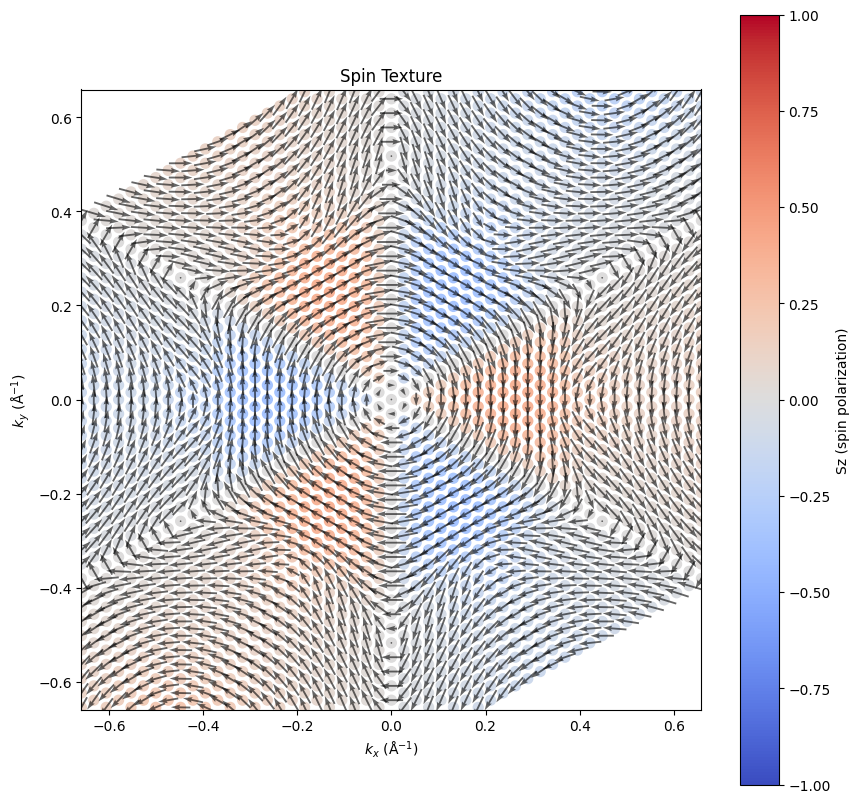

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

# ── Crop to the largest square fully covered by data ─────────────────────────
kx_unique = np.unique(kx)
ky_unique = np.unique(ky)

# For each ky row, find the kx extent; take the tightest (inner square)
kx_min_per_ky = [kx[ky == y].min() for y in ky_unique]
kx_max_per_ky = [kx[ky == y].max() for y in ky_unique]
kx_lo = np.max(kx_min_per_ky)
kx_hi = np.min(kx_max_per_ky)

# For each kx column, find the ky extent; take the tightest
ky_min_per_kx = [ky[kx == x].min() for x in kx_unique]
ky_max_per_kx = [ky[kx == x].max() for x in kx_unique]
ky_lo = np.max(ky_min_per_kx)
ky_hi = np.min(ky_max_per_kx)

# Use the tightest bound across both axes to guarantee no empty corners
k_sq = min(abs(kx_lo), abs(kx_hi), abs(ky_lo), abs(ky_hi))

mask = (np.abs(kx) <= k_sq) & (np.abs(ky) <= k_sq)

kx_p, ky_p = kx[mask], ky[mask]
Sx_p, Sy_p, Sz_p = Sx[mask], Sy[mask], Sz[mask]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx_p, ky_p, c=Sz_p, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

ax.quiver(kx_p, ky_p, Sx_p, Sy_p,
          pivot="mid",
          scale=7,
          scale_units="xy",
          width=0.003,
          color="black",
          alpha=0.6,
          zorder=2)

ax.set_xlim(-k_sq, k_sq)
ax.set_ylim(-k_sq, k_sq)
ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
ax.set_title("Spin Texture")
ax.set_aspect("equal")


#plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()


352


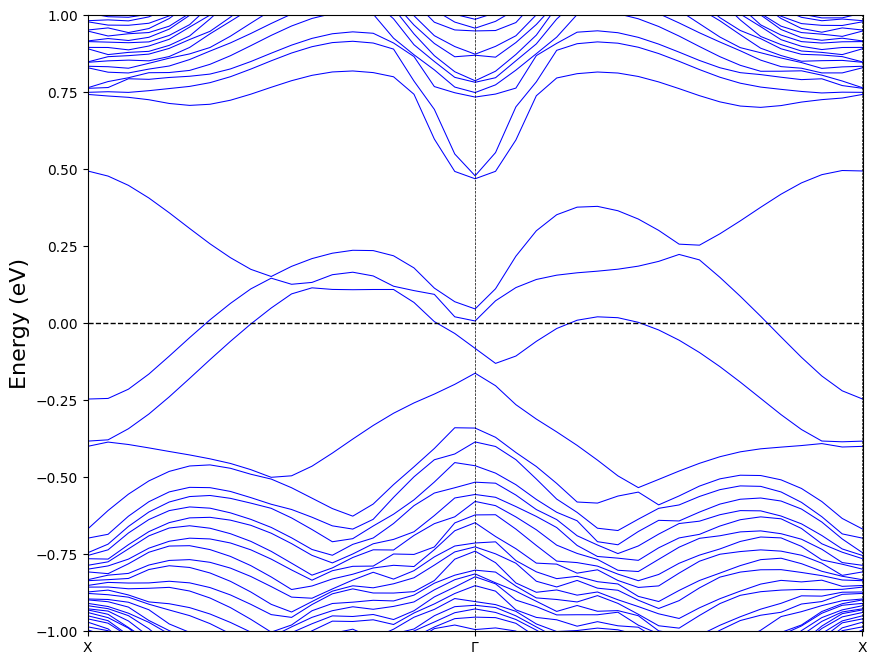

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('fixed-sup-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.672,1.343]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=0.75)

#plt.plot(k, bands[:,277], color='red', lw=1)

plt.axhline(0, color='black', linestyle='--', lw=1)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels)
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-1, 1)
plt.xlim(min(k), max(k))
#plt.axvline(k[29], color='green', linestyle='--', lw=1)
plt.show()


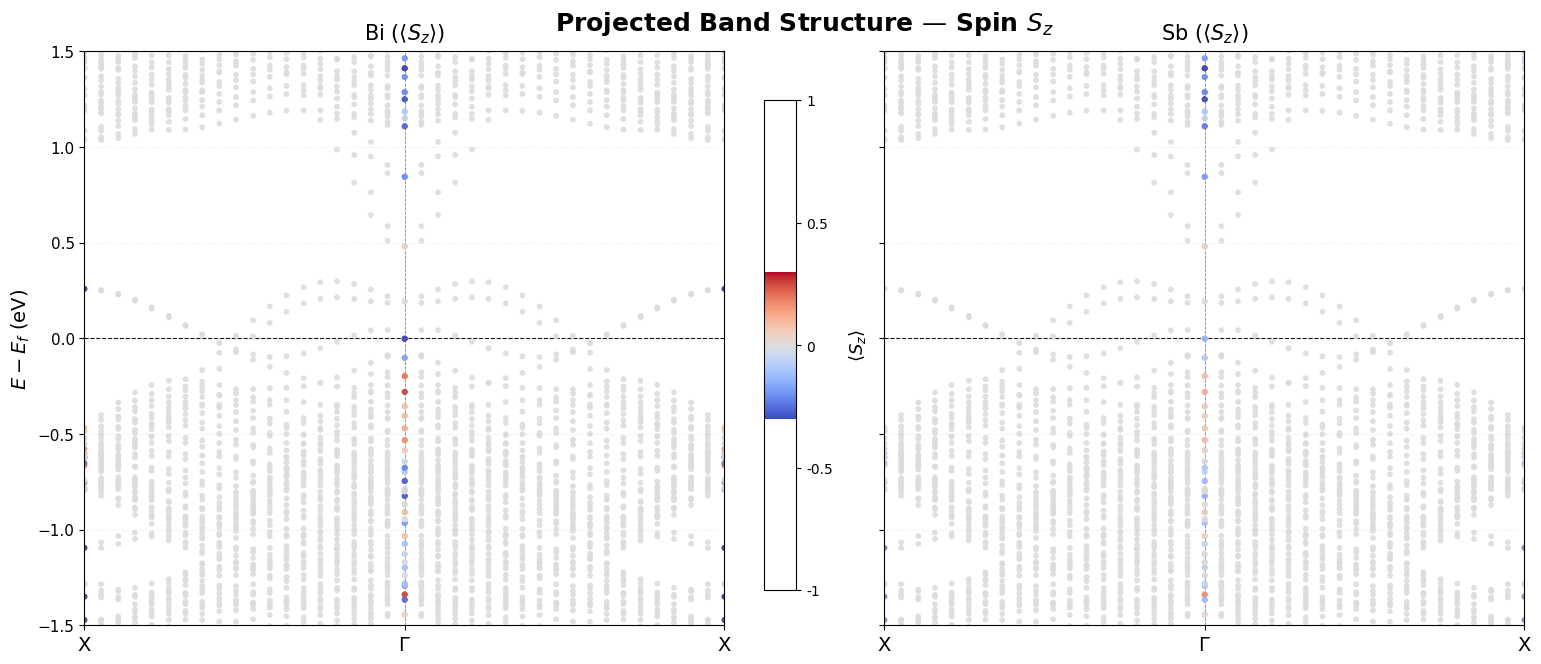

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load Data ---
def load_band_data(filepath):
    return pd.read_csv(filepath, comment='#', sep=r'\s+', header=None, skiprows=2)

data_bi = load_band_data("sup-PBAND_In_SOC_SY.dat")
data_sb = load_band_data("sup-PBAND_Sb_SOC_SY.dat")

k = data_bi[0].to_numpy()
e = data_bi[1].to_numpy()

# --- High-symmetry k-points and labels ---
k_points = [0,0.672,1.343]  
k_labels = ['X', r'$\Gamma$', 'X']

# --- Normalize to [-1, 1] using global abs max ---
spin_bi = data_bi[11].to_numpy()
spin_sb = data_sb[11].to_numpy()

global_absmax = max(np.abs(spin_bi).max(), np.abs(spin_sb).max())

spin_bi_norm = (spin_bi / global_absmax) 
spin_sb_norm = (spin_sb / global_absmax)

# --- Shared norm and colormap ---
CMAP = 'coolwarm'
shared_norm = Normalize(vmin=-0.3, vmax=0.3)

# --- Plot ---
TITLES = [r'Bi ($\langle S_z \rangle$)', r'Sb ($\langle S_z \rangle$)']
spins  = [spin_bi_norm, spin_sb_norm]

fig = plt.figure(figsize=(16, 7))
fig.suptitle(r"Projected Band Structure — Spin $S_z$", fontsize=18, fontweight='bold')

ax_left  = fig.add_axes([0.05, 0.10, 0.40, 0.82])
ax_right = fig.add_axes([0.55, 0.10, 0.40, 0.82])
ax_cbar  = fig.add_axes([0.475, 0.15, 0.02, 0.70])

axes = [ax_left, ax_right]

for ax, spin, title in zip(axes, spins, TITLES):
    ax.scatter(k, e, c=spin, cmap=CMAP, norm=shared_norm, s=10, alpha=0.85, rasterized=True)

    for xv in k_points[1:-1]:
        ax.axvline(xv, ls='--', lw=0.6, color='gray', zorder=0)

    ax.axhline(0, ls='--', lw=0.8, color='black', zorder=0)
    ax.grid(True, which='major', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(k_points[0], k_points[-1])
    ax.set_xticks(k_points)
    ax.set_xticklabels(k_labels, fontsize=14)
    ax.set_title(title, fontsize=15, pad=8)
    ax.tick_params(axis='y', labelsize=11)

ax_left.set_ylabel(r'$E - E_f$ (eV)', fontsize=14)
ax_right.set_yticklabels([])

# --- Centered colorbar ---
sm = ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\langle S_z \rangle$', fontsize=13, labelpad=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=10)

plt.show()